# Глава 2.

### Пономарев Т. Е. 5130901/30201

## Упражнение 2.2

Сигнал «пила» имеет форму волны, которая линейно нарастает от -1 до 1, затем падает до -1 и повторяется. См. http://en.wikipedia.org/wiki/Sawtooth_wave

Напишите класс SawtoothSignal, расширяющий класс Signal и предоставляющий метод evaluate для вычисления сигнала «пила».

Вычислите спектр пилообразной волны. Как гармоническая структура сравнивается со спектрами треугольной и прямоугольной волн?

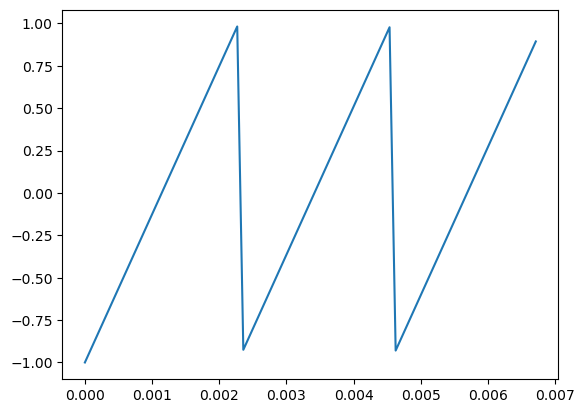

In [4]:
from thinkdsp import Sinusoid, PI2, unbias, normalize, decorate
import numpy as np

class SawtoothSignal (Sinusoid):
    def evaluate(self, ts):
        cycles = self.freq * ts + self.offset / PI2
        frac, _ = np.modf(cycles)
        ys = normalize(unbias(frac), self.amp)
        return ys

saw_sig = SawtoothSignal()
saw_sig.plot()

In [12]:
# Проиграем аудиозапись
saw_sig_wave = saw_sig.make_wave()
saw_sig_wave.make_audio()

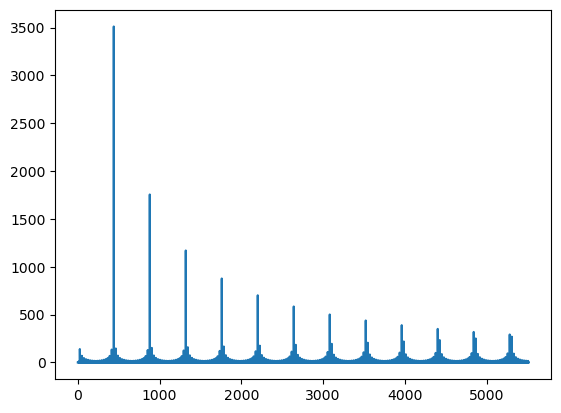

In [11]:
# Рассмотрим спектр
saw_sig_spectrum = saw_sig_wave.make_spectrum()
saw_sig_spectrum.plot()

In [13]:
saw_sig_spectrum.peaks()[:10]

[(np.float64(3510.9599545634615), np.float64(440.0)),
 (np.float64(1755.4817590401092), np.float64(880.0)),
 (np.float64(1170.3231524286894), np.float64(1320.0)),
 (np.float64(877.7444430494716), np.float64(1760.0)),
 (np.float64(702.1976925678606), np.float64(2200.0)),
 (np.float64(585.1669215401175), np.float64(2640.0)),
 (np.float64(501.5738530627456), np.float64(3080.0)),
 (np.float64(438.8793486848431), np.float64(3520.0)),
 (np.float64(390.11722037887927), np.float64(3960.0)),
 (np.float64(351.10775532901044), np.float64(4400.0))]

Интересно, что на графике спектра наблюдаются как нечётные, так и чётные гармоники. Также можно отметить, что амплитуда гармоник спадает пропорционально частоте: $1/f$.

## Упражнение 2.3
Сгенерируйте прямоугольный сигнал с частотой 1100 Гц и создайте волну, которая оцифровывает его со скоростью 10 000 кадров в секунду. Если построить спектр, можно увидеть, что большинство гармоник подвержено эффекту наложения. При прослушивании этой волны слышны ли вам гармоники, подверженные эффекту наложения?

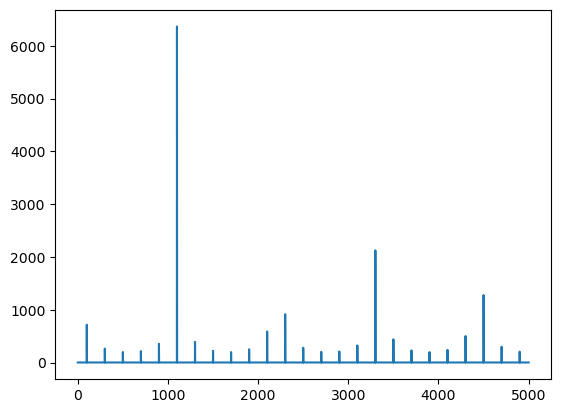

In [19]:
from thinkdsp import SquareSignal

square_sig = SquareSignal(1100)
square_sig_wave = square_sig.make_wave(framerate = 10000)
square_sig_spectrum = square_sig_wave.make_spectrum()
square_sig_spectrum.plot()


In [15]:
saw_sig_spectrum.peaks()[:10]

[(np.float64(3510.9599545634615), np.float64(440.0)),
 (np.float64(1755.4817590401092), np.float64(880.0)),
 (np.float64(1170.3231524286894), np.float64(1320.0)),
 (np.float64(877.7444430494716), np.float64(1760.0)),
 (np.float64(702.1976925678606), np.float64(2200.0)),
 (np.float64(585.1669215401175), np.float64(2640.0)),
 (np.float64(501.5738530627456), np.float64(3080.0)),
 (np.float64(438.8793486848431), np.float64(3520.0)),
 (np.float64(390.11722037887927), np.float64(3960.0)),
 (np.float64(351.10775532901044), np.float64(4400.0))]

In [20]:
square_sig_wave.make_audio()

Да, при прослушивании волны гармоники, которые подвергнуты эффекту наложения, хорошо видны

## Упражнение 2.4
Если у вас есть объект спектра `spectrum` и вы выведете на экран первые несколько значений `spectrum.fs`, то увидите, что частоты начинаются с нуля. Таким образом, `spectrum.hs[0]` — это амплитуда компонента с частотой 0. Но что это означает?

Попробуйте провести следующий эксперимент:

1.    Создайте треугольный сигнал с частотой 440 Гц и объект Wave с длительностью 0,01 секунды. Постройте график формы волны.
2.    Создайте объект Spectrum и выведите `spectrum.hs[0]`. Каковы амплитуда и фаза этой составляющей?
3.    Установите `spectrum.hs[0] = 100`. Создайте Wave из модифицированного Spectrum и постройте его график. Как эта операция влияет на форму волны?

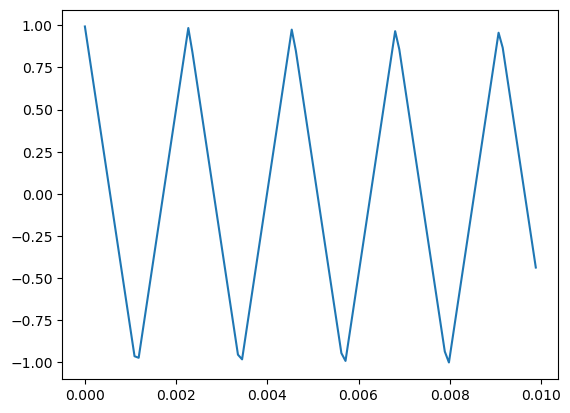

In [27]:
from thinkdsp import TriangleSignal

triangle_sig = TriangleSignal(440)
triangle_sig_wave = triangle_sig.make_wave(duration = 0.01)
triangle_sig_wave.plot()

In [28]:
triangle_sig_spectrum = triangle_sig_wave.make_spectrum()
triangle_sig_spectrum.hs[0]

np.complex128(1.0436096431476471e-14+0j)

1.0436096431476471e-14 - амплитуда. 0 - фаза

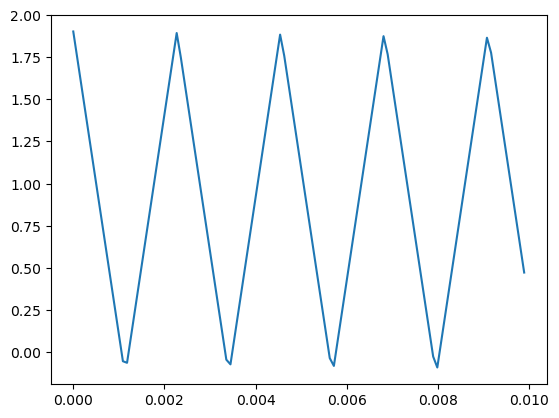

In [29]:
triangle_sig_spectrum.hs[0] = 100
mod_triangle_sig_wave = triangle_sig_spectrum.make_wave()
mod_triangle_sig_wave.plot()

Увеличилась амплитуда сигнала

## Упражнение 2.5
Напишите функцию, принимающую в качестве параметра Spectrum и изменяющую его путем деления каждого элемента hs на соответствующую частоту из fs. Протестируйте свою функцию, используя один из WAV-файлов из репозитория или любой объект Wave.

1. Вычислите спектр и постройте его график.
2. Измените спектр с помощью вашей функции и снова постройте его график.
3. Создайте объект Wave на основе измененного спектра и прослушайте его. Как эта операция влияет на сигнал?

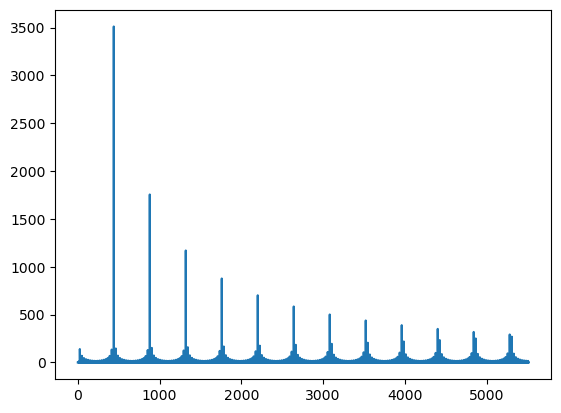

In [42]:
from thinkdsp import Spectrum

def mod_Spectrum(Spectrum):
    Spectrum.hs[0] = 0
    Spectrum.hs[1:] /= Spectrum.fs[1:]
    return Spectrum

sig = SawtoothSignal(freq = 440)
sig_wave = sig.make_wave()

sig_spectrum = sig_wave.make_spectrum()
sig_spectrum.plot()
sig_wave.make_audio()

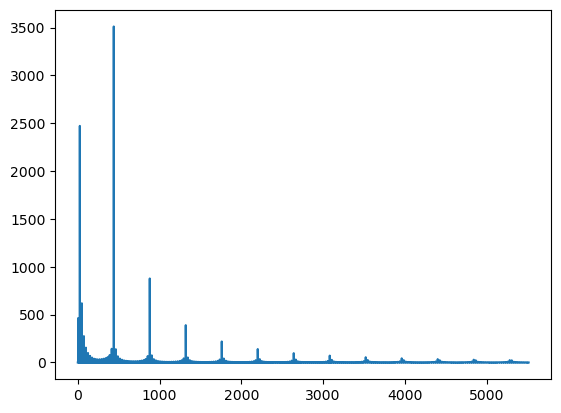

In [43]:
mod_sig_spectrum = mod_Spectrum(sig_spectrum)
mod_sig_spectrum.scale(440)
mod_sig_spectrum.plot()
mod_sig_wave = mod_sig_spectrum.make_wave()
mod_sig_wave.make_audio()

Звук стал заметно глуше


## Упражнение 2.6
Треугольная и прямоугольная волны содержат только нечетные гармоники; пилообразная волна содержит как четные, так и нечетные гармоники. Гармоники прямоугольной и пилообразной волн затухают пропорционально $1/f$; гармоники треугольной волны затухают пропорционально $1/f^2$. Сможете ли вы найти форму сигнала, в которой четные и нечетные гармоники затухают пропорционально $1/f^2$?

Подсказка: Есть два способа решения этой задачи: вы можете
построить нужный сигнал путем сложения синусоидальных сигналов, или вы
можете начать с сигнала, похожего на нужный, и
модифицировать его.

In [38]:
# получили такой сигнал в прошлом упражнении